# AT3 — Chuva forte em Curitiba (R10mm)

Continuação do `atv2_arvore`: regressão só nos dias com chuva ≥ 10 mm. Decisões, achados e referências na última célula.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", context="notebook", palette="deep")
pd.set_option("display.width", 140)

In [2]:
# No Colab, descomente para montar o Drive:
# from google.colab import drive
#
# drive.mount('/content/drive')

In [3]:
from pathlib import Path

PASTA = Path("../../commons/data")
# No Colab, use o caminho do Drive:
# PASTA = Path("/content/drive/MyDrive")

df = pd.read_parquet(PASTA / "curitiba_daily.parquet").sort_values("date").reset_index(drop=True)

# synoptic.py e subdaily.py já deslocam para t-1: o join é sem shift
EXTRAS = []
for nome in ["curitiba_synoptic.parquet", "curitiba_subdaily.parquet"]:
    extra = pd.read_parquet(PASTA / nome)
    df = df.join(extra, on="date")
    EXTRAS += list(extra.columns)

# todos os conjuntos avaliados nas mesmas linhas
df = df.dropna(subset=EXTRAS).reset_index(drop=True)
df.head()

,date,tp_mm,ssrd_wm2,t2m,t2m_min,t2m_max,d2m,dpd,wind_speed,wind_const,...,wind850_const,wind850_dir_sin,wind850_dir_cos,msl_tend,tcwv_tend,cape_tend,cape_max_lag3,tcwv_mean_lag3,wind_max,d2m_range
0,1980-04-01,0.365138,164.091782,16.377014,13.584625,19.219391,13.565399,2.811615,3.557601,0.994403,...,0.995480,0.867004,-0.498302,304.640625,-11.784046,-145.500,326.500,32.290985,4.239836,2.695099
1,1980-04-02,0.120771,179.277222,16.698456,13.498688,21.525055,13.814331,2.884125,2.316316,0.986427,...,0.964308,0.996868,-0.079082,-58.671875,-0.589602,-0.500,165.625,31.707979,3.681856,2.690460
2,1980-04-03,1.311496,195.243958,17.726776,14.785553,22.519684,14.285675,3.441101,1.947963,0.971664,...,0.901211,0.984846,0.173429,-131.968750,1.961582,-4.000,20.125,19.923933,2.749712,3.302399
3,1980-04-04,6.795540,148.697220,18.550293,15.958160,22.249176,16.062836,2.487457,1.714343,0.953920,...,0.983075,0.742985,0.669308,-87.796875,4.041027,-7.500,19.625,19.334332,2.709458,1.601349
4,1980-04-05,2.635221,144.128891,19.203552,17.001373,23.068512,17.138489,2.065063,1.144617,0.389403,...,0.197587,0.530985,-0.847381,-167.140625,10.413525,298.625,15.625,21.295914,1.956160,1.401917


In [4]:
FIGDIR = Path("figuras")
FIGDIR.mkdir(exist_ok=True)

def salvar(nome, fig=None, dpi=200, fechar=False):
    """Salva a figura atual em PNG. Chame ANTES de plt.show()."""
    fig = fig or plt.gcf()
    fig.savefig(FIGDIR / f"{nome}.png", dpi=dpi,
                bbox_inches="tight", facecolor="white")
    print(f"salvo: {nome}.png")
    if fechar:
        plt.close(fig)

## Limiar: R10mm

In [5]:
LIMIAR = 10.0          # R10mm do ETCCDI
ANO_CORTE = 2014       # dev <= 2014, teste >= 2015

df["ano"] = df.date.dt.year
df["mes"] = df.date.dt.month
df["doy"] = df.date.dt.dayofyear
df["forte"] = df.tp_mm >= LIMIAR

n_anos = (df.date.max() - df.date.min()).days / 365.25
chuvoso = df.tp_mm >= 1    # base do percentil no ETCCDI

print(pd.DataFrame({"todos os dias": df.tp_mm.quantile([.5, .9, .95, .99]),
                    "dias chuvosos": df.tp_mm[chuvoso].quantile([.5, .9, .95, .99])}).round(2))
print(f"\ndias chuvosos: {int(chuvoso.sum())} ({100 * chuvoso.mean():.0f}%)")

      todos os dias  dias chuvosos
0.50           0.94           5.33
0.90          12.88          18.94
0.95          18.81          25.70
0.99          36.04          46.58

dias chuvosos: 8195 (49%)


In [6]:
cands = {"R1mm": 1.0, "5 mm": 5.0, "R10mm": LIMIAR, "R20mm": 20.0,
         "p99 chuvosos": float(df.tp_mm[chuvoso].quantile(.99)), "50 mm": 50.0}

limiares = pd.DataFrame([
    {"critério": nome, "limiar_mm": round(u, 1), "n_dias": int((df.tp_mm >= u).sum()),
     "pct_dias": 100 * (df.tp_mm >= u).mean(), "por_ano": (df.tp_mm >= u).sum() / n_anos,
     "n_dev": int((df.tp_mm >= u)[df.ano <= ANO_CORTE].sum()),
     "n_teste": int((df.tp_mm >= u)[df.ano > ANO_CORTE].sum()),
     "pct_da_chuva": 100 * float(df.tp_mm[df.tp_mm >= u].sum() / df.tp_mm.sum())}
    for nome, u in cands.items()])
print(limiares.round(1).to_string(index=False))

    critério  limiar_mm  n_dias  pct_dias  por_ano  n_dev  n_teste  pct_da_chuva
        R1mm        1.0    8195      49.0    179.1   6265     1930          97.3
        5 mm        5.0    4258      25.5     93.1   3275      983          83.6
       R10mm       10.0    2395      14.3     52.4   1857      538          64.6
       R20mm       20.0     722       4.3     15.8    572      150          31.9
p99 chuvosos       46.6      82       0.5      1.8     67       15           7.0
       50 mm       50.0      62       0.4      1.4     50       12           5.7


salvo: limiar.png


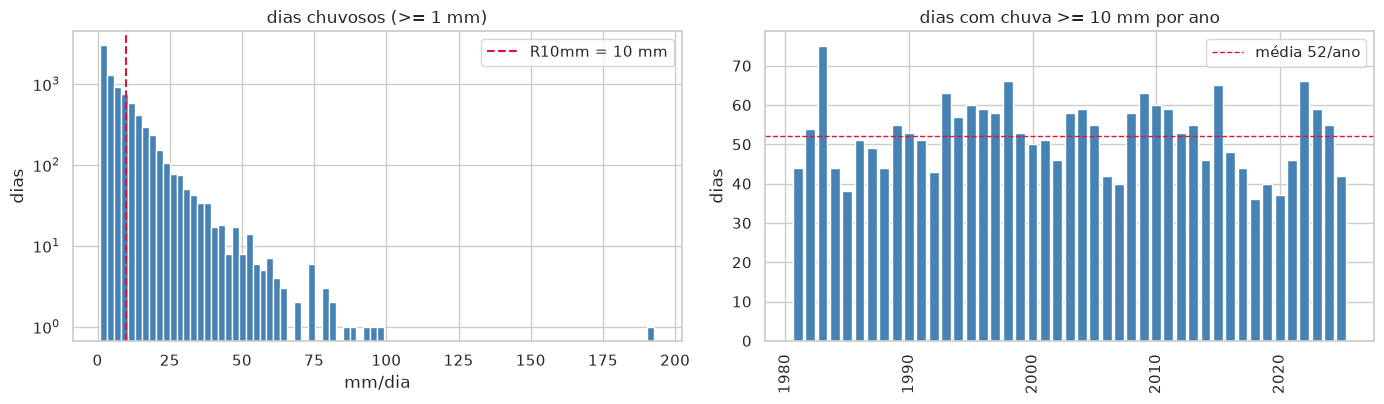

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))

axes[0].hist(df.tp_mm[chuvoso], bins=80, color="steelblue")
axes[0].axvline(LIMIAR, color="crimson", ls="--", lw=1.5, label=f"R10mm = {LIMIAR:g} mm")
axes[0].set(title="dias chuvosos (>= 1 mm)", xlabel="mm/dia", ylabel="dias", yscale="log")
axes[0].legend()

completos = df.groupby("ano").size() > 360
por_ano = df[df.ano.isin(completos[completos].index)].groupby("ano").forte.sum()
axes[1].bar(por_ano.index, por_ano.values, color="steelblue")
axes[1].axhline(por_ano.mean(), color="crimson", ls="--", lw=1, label=f"média {por_ano.mean():.0f}/ano")
axes[1].set(title=f"dias com chuva >= {LIMIAR:g} mm por ano", xlabel="", ylabel="dias")
axes[1].tick_params(axis="x", rotation=90)
axes[1].legend()

plt.tight_layout()
salvar("limiar")
plt.show()

## Faixas disjuntas

`tp_sum7/30/90` são aninhados; as faixas cobrem os mesmos 90 dias sem sobreposição (mesma operação de `bands.py`).

In [8]:
ANINHADAS = ["tp_sum7", "tp_sum30", "tp_sum90"]
FAIXAS    = ["tp_d1_7", "tp_d8_30", "tp_d31_90"]

df["tp_d1_7"]   = df.tp_sum7                   # t-7  a t-1
df["tp_d8_30"]  = df.tp_sum30 - df.tp_sum7     # t-30 a t-8
df["tp_d31_90"] = df.tp_sum90 - df.tp_sum30    # t-90 a t-31

assert np.allclose(df[FAIXAS].sum(axis=1), df.tp_sum90, atol=1e-3)
assert (df[FAIXAS] >= -1e-6).all().all()

comp = pd.DataFrame({
    "corr_alvo_aninhada": [df.tp_mm.corr(df[c], method="spearman") for c in ANINHADAS],
    "corr_alvo_faixa":    [df.tp_mm.corr(df[c], method="spearman") for c in FAIXAS],
    "autocorr_lag1":      [df[c].autocorr(1) for c in FAIXAS],
}, index=["7 dias", "8-30 dias", "31-90 dias"])
print(comp.round(3))

            corr_alvo_aninhada  corr_alvo_faixa  autocorr_lag1
7 dias                   0.306            0.306          0.920
8-30 dias                0.300            0.240          0.983
31-90 dias               0.259            0.158          0.995


salvo: faixas_correlacao.png


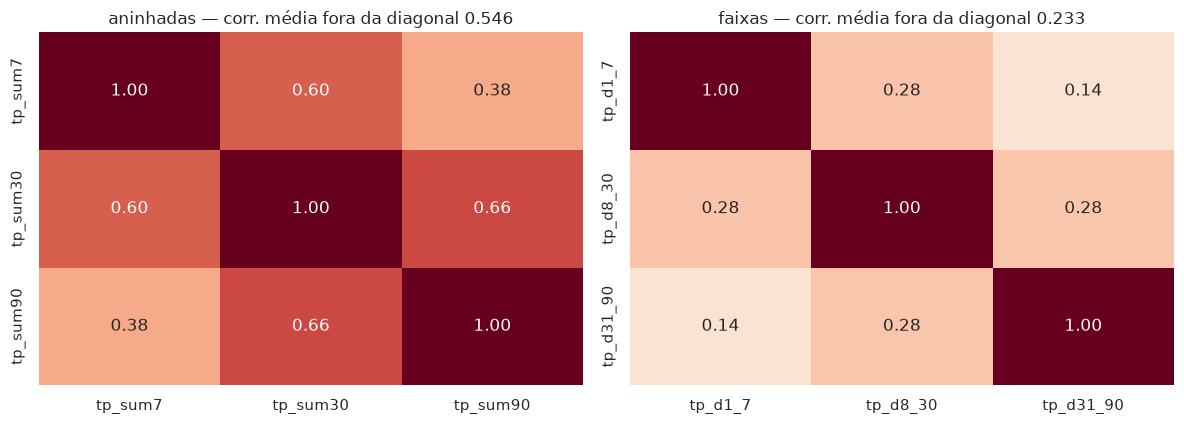

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
for ax, cols, titulo in zip(axes, [ANINHADAS, FAIXAS], ["aninhadas", "faixas"]):
    c = df[cols].corr("spearman")
    sns.heatmap(c, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, ax=ax, cbar=False)
    fora = c.values[np.triu_indices(3, 1)]
    ax.set(title=f"{titulo} — corr. média fora da diagonal {fora.mean():.3f}")
plt.tight_layout()
salvar("faixas_correlacao")
plt.show()

## Subamostra de dias fortes

In [10]:
sub = df[df.forte].reset_index(drop=True)

print(f"dias fortes: {len(sub)} ({100 * df.forte.mean():.1f}% da série, {len(sub) / n_anos:.0f}/ano)")
print(f"dev: {int((sub.ano <= ANO_CORTE).sum())} | teste: {int((sub.ano > ANO_CORTE).sum())}")
print(f"alvo: média {sub.tp_mm.mean():.1f} | mediana {sub.tp_mm.median():.1f} | "
      f"máx {sub.tp_mm.max():.1f} | std {sub.tp_mm.std():.2f} mm")

saz = pd.DataFrame({"dias_fortes": sub.mes.value_counts().sort_index(),
                    "dias_totais": df.mes.value_counts().sort_index()})
saz["pct_do_mes_forte"]  = 100 * saz.dias_fortes / saz.dias_totais
saz["pct_da_subamostra"] = 100 * saz.dias_fortes / len(sub)
saz["intensidade_media"] = sub.groupby("mes").tp_mm.mean()
print("\n", saz.round(1))

dias fortes: 2395 (14.3% da série, 52/ano)
dev: 1857 | teste: 538
alvo: média 19.2 | mediana 15.7 | máx 192.7 | std 11.34 mm

      dias_fortes  dias_totais  pct_do_mes_forte  pct_da_subamostra  intensidade_media
mes                                                                                  
1            363         1395              26.0               15.2          18.100000
2            289         1271              22.7               12.1          17.600000
3            195         1395              14.0                8.1          15.800000
4            102         1380               7.4                4.3          19.700001
5            147         1426              10.3                6.1          21.799999
6            147         1380              10.7                6.1          21.700001
7            124         1426               8.7                5.2          24.100000
8            125         1426               8.8                5.2          21.700001
9            

salvo: sazonalidade.png


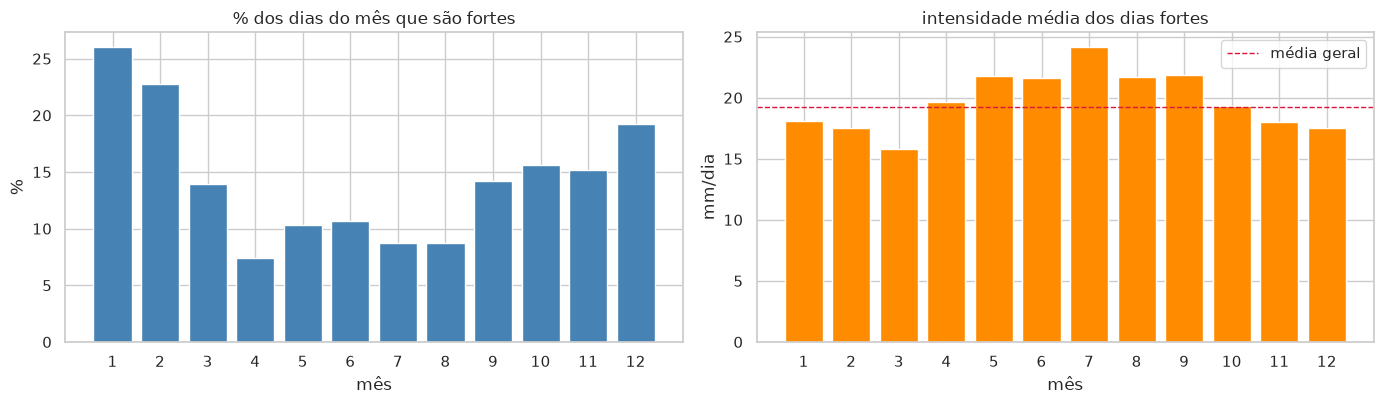

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))

axes[0].bar(saz.index, saz.pct_do_mes_forte, color="steelblue")
axes[0].set(title="% dos dias do mês que são fortes", xlabel="mês", ylabel="%")
axes[0].set_xticks(range(1, 13))

axes[1].bar(saz.index, saz.intensidade_media, color="darkorange")
axes[1].axhline(sub.tp_mm.mean(), color="crimson", ls="--", lw=1, label="média geral")
axes[1].set(title="intensidade média dos dias fortes", xlabel="mês", ylabel="mm/dia")
axes[1].set_xticks(range(1, 13))
axes[1].legend()

plt.tight_layout()
salvar("sazonalidade")
plt.show()

## Dependência temporal

In [12]:
ac = pd.DataFrame({
    "forte (série)":      {k: df.forte.astype(float).autocorr(k) for k in (1, 2, 3, 7, 30)},
    "tp_mm (subamostra)": {k: sub.tp_mm.autocorr(k) for k in (1, 2, 3)},
})
ac.index.name = "lag"
print(ac.round(3))

     forte (série)  tp_mm (subamostra)
lag                                   
1            0.218               0.065
2            0.055               0.052
3            0.026               0.023
7            0.037                 NaN
30           0.008                 NaN


In [13]:
# índice extremal θ pelo método de runs (r = 1): dias contíguos formam um episódio
bloco = (df.forte != df.forte.shift()).cumsum()
runs = df[df.forte].groupby(bloco[df.forte]).agg(
    n=("tp_mm", "size"), ini=("date", "first"), fim=("date", "last"), total=("tp_mm", "sum"))
theta = len(runs) / df.forte.sum()
maior = runs.loc[runs.n.idxmax()]

print(f"episódios: {len(runs)} | duração média: {runs.n.mean():.2f} dias | θ = {theta:.3f}")
print(f"maior: {maior.n} dias, {maior.ini:%Y-%m-%d} a {maior.fim:%Y-%m-%d}, {maior.total:.0f} mm")
print(runs.n.value_counts().sort_index().rename("episódios").to_string())

episódios: 1605 | duração média: 1.49 dias | θ = 0.670
maior: 7 dias, 1990-01-06 a 1990-01-12, 179 mm
n
1    1062
2     375
3     109
4      46
5       9
6       1
7       3


## Divisão temporal

Folds por data, não por linha: na subamostra, `test_size=365*4` seriam ~27 anos. Mesma `date_folds` de `evaluation.py`.

In [14]:
def date_folds(dates, n_splits=5, val_years=4, end=None):
    """Folds de janela expansiva sobre blocos de calendário, como um splitter do sklearn."""
    dates = pd.to_datetime(pd.Series(dates)).reset_index(drop=True)
    end = dates.max().normalize() + pd.Timedelta(days=1) if end is None else pd.Timestamp(end)
    bordas = [end - pd.DateOffset(years=val_years * k) for k in range(n_splits + 1)][::-1]
    folds = []
    for ini, fim in zip(bordas[:-1], bordas[1:]):
        tr = np.where(dates < ini)[0]
        va = np.where((dates >= ini) & (dates < fim))[0]
        if len(tr) and len(va):
            folds.append((tr, va))
    return folds

dev   = sub[sub.ano <= ANO_CORTE].reset_index(drop=True)
teste = sub[sub.ano >  ANO_CORTE].reset_index(drop=True)   # tocado uma única vez, no fim
y_te  = teste.tp_mm
folds = date_folds(dev.date, n_splits=5, val_years=4, end=f"{ANO_CORTE + 1}-01-01")

periodos = pd.DataFrame([
    {"fold": k, "treino_até": dev.date[tr[-1]].date(), "n_treino": len(tr),
     "val_ini": dev.date[va[0]].date(), "val_fim": dev.date[va[-1]].date(), "n_val": len(va)}
    for k, (tr, va) in enumerate(folds, 1)])
print(periodos.to_string(index=False))

 fold treino_até  n_treino    val_ini    val_fim  n_val
    1 1994-12-31       766 1995-01-02 1998-12-29    243
    2 1998-12-29      1009 1999-01-01 2002-12-25    200
    3 2002-12-25      1209 2003-01-04 2006-12-24    214
    4 2006-12-24      1423 2007-01-04 2010-12-26    221
    5 2010-12-26      1644 2011-01-07 2014-12-26    213


## Baselines

In [15]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def rmse(y, p):
    return mean_squared_error(y, p) ** .5

def baselines(treino, alvo_df):
    """Climatologia mensal refeita sobre a subamostra, ajustada só no treino."""
    clim = treino.groupby(treino.date.dt.month).tp_mm.mean()
    return {
        "climatologia mensal": alvo_df.date.dt.month.map(clim).fillna(treino.tp_mm.mean()).to_numpy(),
        "média (dev)":   np.full(len(alvo_df), treino.tp_mm.mean()),
        "mediana (dev)": np.full(len(alvo_df), treino.tp_mm.median()),
        "persistência":  alvo_df.tp_lag1.to_numpy(),
    }

base = pd.DataFrame([{"baseline": k, "RMSE": rmse(y_te, v), "MAE": mean_absolute_error(y_te, v)}
                     for k, v in baselines(dev, teste).items()]).set_index("baseline")
print(base.sort_values("RMSE").round(3))
print(f"\nstd do alvo no teste: {y_te.std():.3f} mm")

                       RMSE     MAE
baseline                           
climatologia mensal  10.285   6.936
média (dev)          10.323   7.076
mediana (dev)        10.897   6.442
persistência         17.516  13.756

std do alvo no teste: 10.328 mm


## Features

40 → 29 por redundância (`|Spearman| > 0,85` entre features, cego ao alvo); 29 → 20 sem as 9 que nenhuma árvore usa (célula de uso abaixo).

In [16]:
MET   = ["ssrd_wm2", "t2m", "d2m", "dpd", "wind_speed", "wind_const"]
CICLO = ["wind_dir_sin", "wind_dir_cos", "day_sin", "day_cos"]

# importância zero em todos os folds (profundidade 4, folha 50), medida na célula de uso por fold
IMPORTANCIA_ZERO = ["cape_max", "cape_max_lag3", "cape_tend", "d2m_range", "msl_min",
                "tcwv_mean_lag3", "tp_lag2", "wind850_const", "wind_speed"]

SEM_REDUNDANCIA = (MET + CICLO + ["tp_lag1", "tp_lag2", "tp_lag3"]
          + ["dpd_lag2", "d2m_lag2", "dpd_lag3"]
          + ["cape_max", "tcwv_mean", "msl_min", "msl_tend", "tcwv_tend", "cape_tend",
             "wind850_speed_mean", "wind850_const", "wind850_dir_sin", "wind850_dir_cos",
             "cape_max_lag3", "tcwv_mean_lag3", "d2m_range"])

CONJUNTOS = {
    "vespera":      MET + CICLO + ["tp_lag1"],                         # 11, referência atv2
    "so_atmosfera": MET + CICLO,                                       # 10
    "vespera+850":  MET + CICLO + ["tp_lag1", "wind850_speed_mean"],   # 12
    "sem_redundancia": [c for c in SEM_REDUNDANCIA if c not in IMPORTANCIA_ZERO],  # 20
}
for k, v in CONJUNTOS.items():
    print(f"{k:14s} {len(v):2d} features")

vespera        11 features
so_atmosfera   10 features
vespera+850    12 features
sem_redundancia 20 features


In [17]:
# descritiva, só no dev — não foi ela que escolheu as features
TODAS = sorted({c for v in CONJUNTOS.values() for c in v})
df_dev, sub_dev = df[df.ano <= ANO_CORTE], sub[sub.ano <= ANO_CORTE]

sinal = pd.DataFrame({
    "serie_toda":  [df_dev.tp_mm.corr(df_dev[c], method="spearman") for c in TODAS],
    "dias_fortes": [sub_dev.tp_mm.corr(sub_dev[c], method="spearman") for c in TODAS],
}, index=TODAS)
print(sinal.sort_values("dias_fortes", key=abs, ascending=False).round(3))

                    serie_toda  dias_fortes
wind850_speed_mean       0.093        0.212
ssrd_wm2                -0.050       -0.177
day_cos                  0.370       -0.167
wind_speed               0.046        0.158
d2m_lag2                 0.390       -0.119
wind_dir_cos             0.141        0.118
t2m                      0.373       -0.116
d2m                      0.486       -0.113
tcwv_tend                0.287        0.113
wind850_dir_sin          0.000       -0.097
day_sin                  0.059       -0.095
tp_lag3                  0.191       -0.090
wind850_dir_cos          0.159        0.080
wind_dir_sin            -0.019       -0.074
wind_const              -0.048        0.069
tp_lag1                  0.536        0.068
msl_tend                -0.108       -0.065
dpd                     -0.327       -0.046
tcwv_mean                0.576       -0.030
dpd_lag3                -0.047        0.029
dpd_lag2                -0.129       -0.004


## Machine Learning

#### Configurações

In [18]:
from itertools import product
from sklearn.tree import DecisionTreeRegressor, export_text, plot_tree

SEED = 42
CRIT = ["poisson", "squared_error"]    # qual vence é resultado a reportar

GRADE = (
    [{"criterion": c, "max_depth": d, "min_samples_leaf": f}
     for c, d, f in product(CRIT, [3, 4, 5, 8], [20, 50, 100, 200])]
    + [{"criterion": c, "min_samples_leaf": 20, "ccp_alpha": a}
       for c, a in product(CRIT, [0.01, 0.1, 0.5, 2.0, 5.0])]
    + [{"criterion": c, "min_samples_leaf": 20, "min_impurity_decrease": m}
       for c, m in product(CRIT, [0.5, 1.0, 2.0])]
)
print(f"{len(CONJUNTOS)} conjuntos × {len(GRADE)} hiperparâmetros = "
      f"{len(CONJUNTOS) * len(GRADE)} modelos")

4 conjuntos × 48 hiperparâmetros = 192 modelos


#### Uso das features por fold

In [19]:
uso = pd.DataFrame(0, index=SEM_REDUNDANCIA, columns=[f"fold{i+1}" for i in range(len(folds))])
for i, (i_tr, _) in enumerate(folds):
    m = DecisionTreeRegressor(random_state=SEED, criterion="poisson", max_depth=4,
                              min_samples_leaf=50).fit(dev.iloc[i_tr][SEM_REDUNDANCIA], dev.iloc[i_tr].tp_mm)
    uso.iloc[:, i] = (m.feature_importances_ > 0).astype(int)
uso["n_folds"] = uso.sum(axis=1)

print("nunca usadas:", sorted(uso[uso.n_folds == 0].index))
print("usadas em >= 4 folds:", sorted(uso[uso.n_folds >= 4].index))

nunca usadas: ['cape_max', 'cape_max_lag3', 'cape_tend', 'd2m_range', 'msl_min', 'tcwv_mean_lag3', 'tp_lag2', 'wind850_const', 'wind_speed']
usadas em >= 4 folds: ['day_cos', 'tp_lag1', 'wind850_speed_mean']


#### Ajuste de Hiperparâmetros

In [20]:
def rotulo(cj, hp):
    curto = {"criterion": "crit", "max_depth": "d", "min_samples_leaf": "leaf",
             "ccp_alpha": "ccp", "min_impurity_decrease": "mid"}
    return f"{cj} | " + " ".join(f"{curto[k]}={v}" for k, v in hp.items())

linhas, config, porfold = [], {}, {}
for (cj, cols), hp in product(CONJUNTOS.items(), GRADE):
    r, mae, r_in, nf = [], [], [], []
    for i_tr, i_va in folds:
        tr, va = dev.iloc[i_tr], dev.iloc[i_va]
        m = DecisionTreeRegressor(random_state=SEED, **hp).fit(tr[cols], tr.tp_mm)
        p = m.predict(va[cols])
        r.append(rmse(va.tp_mm, p))
        mae.append(mean_absolute_error(va.tp_mm, p))
        r_in.append(rmse(tr.tp_mm, m.predict(tr[cols])))
        nf.append(m.get_n_leaves())
    chave = rotulo(cj, hp)
    config[chave] = (cols, hp)
    porfold[chave] = np.array(r)       # o teste pareado usa cada fold
    linhas.append({"modelo": chave, "conjunto": cj, "crit": hp["criterion"],
                   "n_feats": len(cols), "RMSE_cv": np.mean(r), "RMSE_std": np.std(r),
                   "MAE_cv": np.mean(mae), "RMSE_treino": np.mean(r_in), "folhas": np.mean(nf)})

res = pd.DataFrame(linhas).set_index("modelo").sort_values("RMSE_cv")
res["gap"] = res.RMSE_cv - res.RMSE_treino
print(res.head(10).round(3).to_string())

print("\nMelhor por conjunto de features")
print(res.loc[res.groupby("conjunto").RMSE_cv.idxmin(),
              ["conjunto", "n_feats", "RMSE_cv", "RMSE_std", "MAE_cv", "folhas"]].round(3).to_string())
print("\ncritério no top 10:", res.head(10).crit.value_counts().to_dict())

                                                  conjunto           crit  n_feats  RMSE_cv  RMSE_std  MAE_cv  RMSE_treino  folhas    gap
modelo                                                                                                                                   
vespera+850 | crit=poisson d=4 leaf=50         vespera+850        poisson       12   11.494     2.476   7.248       10.857     9.8  0.637
vespera+850 | crit=squared_error d=4 leaf=50   vespera+850  squared_error       12   11.528     2.455   7.263       10.863     9.8  0.665
vespera+850 | crit=poisson d=3 leaf=50         vespera+850        poisson       12   11.560     2.455   7.271       10.938     6.8  0.622
vespera+850 | crit=poisson d=5 leaf=50         vespera+850        poisson       12   11.573     2.439   7.265       10.789    13.2  0.784
vespera+850 | crit=squared_error d=3 leaf=50   vespera+850  squared_error       12   11.583     2.443   7.281       10.946     6.8  0.637
vespera+850 | crit=poisson d=5 lea

salvo: cv_modelos.png


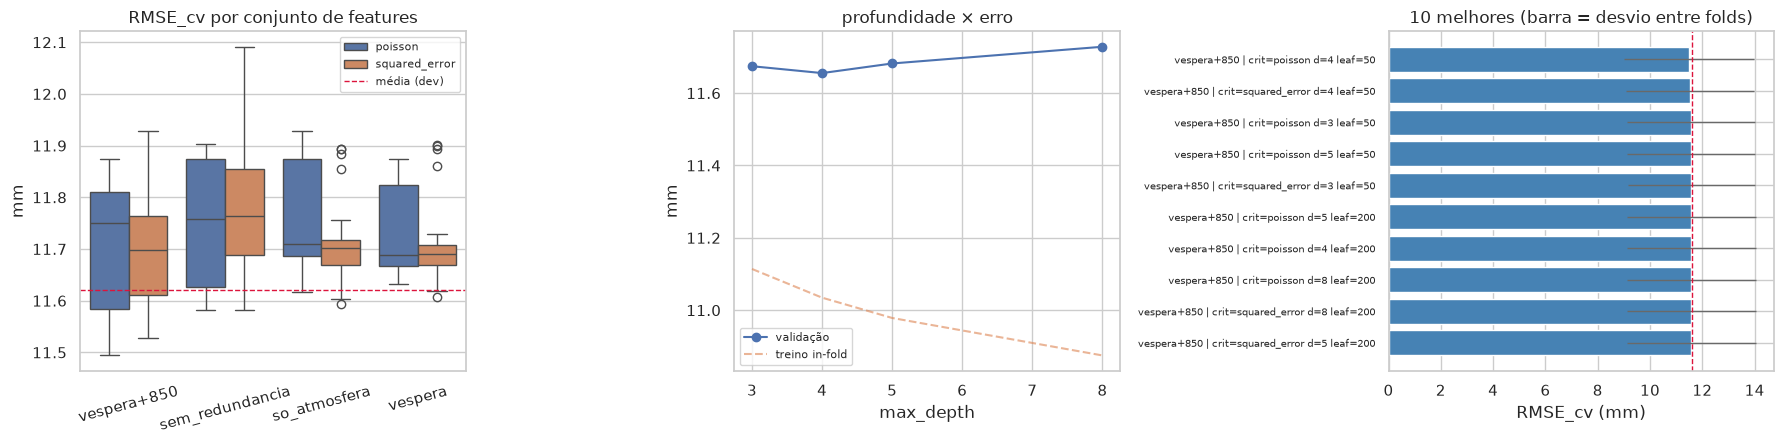

In [21]:
rmse_media = rmse(dev.tp_mm, np.full(len(dev), dev.tp_mm.mean()))

fig, axes = plt.subplots(1, 3, figsize=(18, 4.6))

sns.boxplot(data=res.reset_index(), x="conjunto", y="RMSE_cv", hue="crit", ax=axes[0])
axes[0].axhline(rmse_media, color="crimson", ls="--", lw=1, label="média (dev)")
axes[0].set(title="RMSE_cv por conjunto de features", xlabel="", ylabel="mm")
axes[0].tick_params(axis="x", rotation=15)
axes[0].legend(fontsize=8)

prof = res.reset_index()
prof["d"] = prof.modelo.str.extract(r"\bd=(\d+)")[0].astype(float)
med = prof.dropna(subset=["d"]).groupby("d")[["RMSE_cv", "RMSE_treino"]].mean()
axes[1].plot(med.index, med.RMSE_cv, "-o", label="validação")
axes[1].plot(med.index, med.RMSE_treino, "--", alpha=.6, label="treino in-fold")
axes[1].set(title="profundidade × erro", xlabel="max_depth", ylabel="mm")
axes[1].legend(fontsize=8)

top = res.nsmallest(10, "RMSE_cv").iloc[::-1]
axes[2].barh(range(len(top)), top.RMSE_cv, xerr=top.RMSE_std, color="steelblue",
             error_kw={"lw": 1, "ecolor": "dimgray"})
axes[2].axvline(rmse_media, color="crimson", ls="--", lw=1)
axes[2].set_yticks(range(len(top)))
axes[2].set_yticklabels(top.index, fontsize=7)
axes[2].set(title="10 melhores (barra = desvio entre folds)", xlabel="RMSE_cv (mm)")

plt.tight_layout()
salvar("cv_modelos")
plt.show()

#### Teste pareado por fold

Diagnóstico, não seleção: a variância entre folds é comum a todos os modelos, então a comparação é sobre as diferenças por fold.

In [22]:
ff = pd.DataFrame(porfold).T
ff.columns = [f"fold{i+1}" for i in range(len(folds))]
print("RMSE médio por fold:", ff.mean(axis=0).round(3).to_dict())
print(f"desvio entre folds: {ff.mean(axis=0).std(ddof=1):.3f} | "
      f"entre modelos: {res.RMSE_cv.std(ddof=1):.3f} mm")

argmin = res.RMSE_cv.idxmin()
dif = ff.sub(ff.loc[argmin], axis=1)
se = dif.std(axis=1, ddof=1) / np.sqrt(len(folds))
par = pd.DataFrame({"dif_media": dif.mean(axis=1), "SE_pareado": se,
                    "t": (dif.mean(axis=1) / se).where(se > 0, 0.0)}).join(
                        res[["RMSE_cv", "folhas", "n_feats"]])

se_marg = res.loc[argmin, "RMSE_std"] / np.sqrt(len(folds))
print(f"\nSE marginal: {se_marg:.3f} mm -> "
      f"{int((res.RMSE_cv <= res.RMSE_cv.min() + se_marg).sum())} de {len(res)} elegíveis")
print(f"SE pareado (mediano): {par.SE_pareado[par.SE_pareado > 0].median():.3f} mm")
print(f"indistinguíveis do melhor (|t| < 2): {int((par.t.abs() < 2).sum())} de {len(par)}")

stumps = par[par.folhas == 1]
if len(stumps):
    s0 = stumps.RMSE_cv.idxmin()
    print(f"árvore de 1 folha vs melhor: {par.dif_media[s0]:+.3f} ± {par.SE_pareado[s0]:.3f} mm, "
          f"t = {par.t[s0]:+.2f}")

RMSE médio por fold: {'fold1': 16.475, 'fold2': 10.852, 'fold3': 10.706, 'fold4': 9.922, 'fold5': 10.707}
desvio entre folds: 2.676 | entre modelos: 0.109 mm

SE marginal: 1.107 mm -> 192 de 192 elegíveis
SE pareado (mediano): 0.248 mm
indistinguíveis do melhor (|t| < 2): 179 de 192
árvore de 1 folha vs melhor: +0.380 ± 0.344 mm, t = +1.10


#### Treino e teste

In [23]:
melhor = res.RMSE_cv.idxmin()      # selecionado na CV
cols, hp = config[melhor]
print("selecionado:", melhor)
print(res.loc[melhor, ["RMSE_cv", "RMSE_std", "MAE_cv", "folhas"]].astype(float).round(3).to_dict(),
      f"| t vs melhor {par.t[melhor]:+.2f}\n")

final = DecisionTreeRegressor(random_state=SEED, **hp).fit(dev[cols], dev.tp_mm)
p_fin = final.predict(teste[cols])

preds = {f"ÁRVORE — {melhor}": p_fin, **baselines(dev, teste)}
fin = pd.DataFrame([{"modelo": n, "RMSE": rmse(y_te, p), "MAE": mean_absolute_error(y_te, p)}
                    for n, p in preds.items()]).set_index("modelo").sort_values("RMSE")
fin["vs_clim_%"] = 100 * (1 - fin.RMSE / fin.loc["climatologia mensal", "RMSE"])
print(fin.round(3).to_string())

selecionado: vespera+850 | crit=poisson d=4 leaf=50
{'RMSE_cv': 11.494, 'RMSE_std': 2.476, 'MAE_cv': 7.248, 'folhas': 9.8} | t vs melhor +0.00

                                                   RMSE     MAE  vs_clim_%
modelo                                                                    
climatologia mensal                              10.285   6.936      0.000
média (dev)                                      10.323   7.076     -0.368
ÁRVORE — vespera+850 | crit=poisson d=4 leaf=50  10.418   6.991     -1.286
mediana (dev)                                    10.897   6.442     -5.949
persistência                                     17.516  13.756    -70.297


salvo: teste_final.png


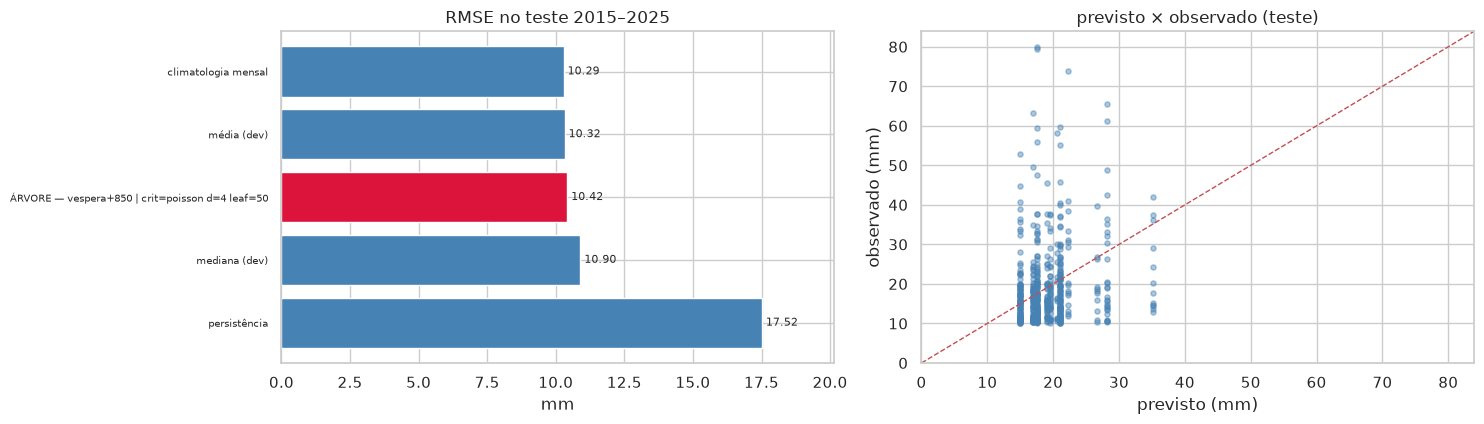

previsões: 15.0 a 35.1 mm | observado: 10.0 a 79.9 mm


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.4))

d = fin.sort_values("RMSE")
axes[0].barh(range(len(d)), d.RMSE,
             color=["crimson" if i.startswith("ÁRVORE") else "steelblue" for i in d.index])
axes[0].set_yticks(range(len(d)))
axes[0].set_yticklabels(d.index, fontsize=7)
axes[0].invert_yaxis()
axes[0].set(title=f"RMSE no teste {teste.ano.min()}–{teste.ano.max()}", xlabel="mm")
axes[0].set_xlim(0, d.RMSE.max() * 1.15)
for i, v in enumerate(d.RMSE):
    axes[0].text(v, i, f" {v:.2f}", va="center", fontsize=8)

lim = [0, y_te.max() * 1.05]
axes[1].scatter(p_fin, y_te, s=14, alpha=.45, color="steelblue")
axes[1].plot(lim, lim, "r--", lw=1)
axes[1].set(title="previsto × observado (teste)", xlabel="previsto (mm)",
            ylabel="observado (mm)", xlim=lim, ylim=lim)

plt.tight_layout()
salvar("teste_final")
plt.show()

print(f"previsões: {p_fin.min():.1f} a {p_fin.max():.1f} mm | observado: {y_te.min():.1f} a {y_te.max():.1f} mm")

#### Árvore de Decisão

In [25]:
print(f"{final.get_n_leaves()} folhas, profundidade {final.get_depth()}\n")
print(export_text(final, feature_names=list(cols), max_depth=3, decimals=1))

11 folhas, profundidade 4

|--- wind850_speed_mean <= 10.8
|   |--- ssrd_wm2 <= 181.5
|   |   |--- tp_lag1 <= 21.0
|   |   |   |--- wind_dir_cos <= 0.4
|   |   |   |   |--- value: [17.6]
|   |   |   |--- wind_dir_cos >  0.4
|   |   |   |   |--- value: [21.0]
|   |   |--- tp_lag1 >  21.0
|   |   |   |--- day_sin <= 0.1
|   |   |   |   |--- value: [20.6]
|   |   |   |--- day_sin >  0.1
|   |   |   |   |--- value: [26.7]
|   |--- ssrd_wm2 >  181.5
|   |   |--- day_sin <= -0.9
|   |   |   |--- value: [19.0]
|   |   |--- day_sin >  -0.9
|   |   |   |--- wind_dir_sin <= -0.3
|   |   |   |   |--- value: [16.9]
|   |   |   |--- wind_dir_sin >  -0.3
|   |   |   |   |--- value: [15.0]
|--- wind850_speed_mean >  10.8
|   |--- wind850_speed_mean <= 15.6
|   |   |--- wind_dir_cos <= 0.7
|   |   |   |--- value: [19.6]
|   |   |--- wind_dir_cos >  0.7
|   |   |   |--- day_sin <= -0.0
|   |   |   |   |--- value: [28.2]
|   |   |   |--- day_sin >  -0.0
|   |   |   |   |--- value: [22.3]
|   |--- wind85

salvo: arvore_topo.png


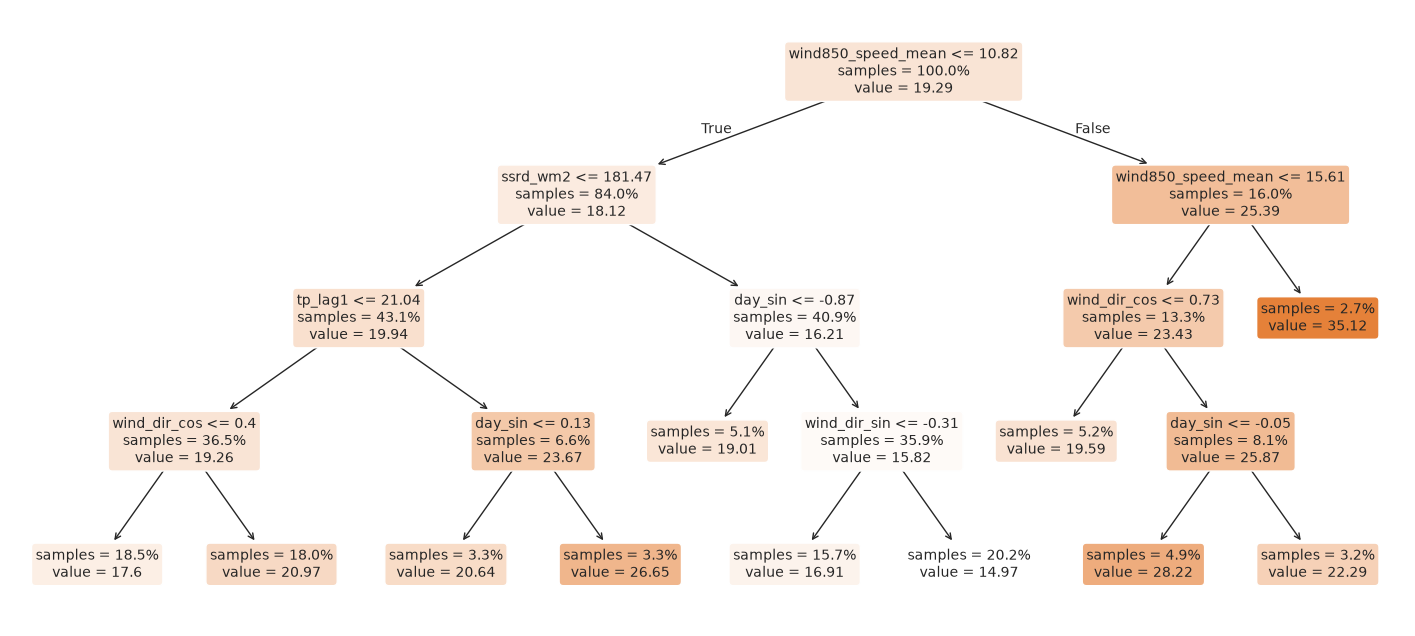

In [26]:
# desenhada com o matplotlib, sem depender do Graphviz instalado no sistema
fig, ax = plt.subplots(figsize=(18, 8))
plot_tree(final, feature_names=list(cols), filled=True, rounded=True,          # a árvore inteira: só 4 níveis
          impurity=False, proportion=True, precision=2, fontsize=10, ax=ax)
salvar("arvore_topo")
plt.show()

#### Importância das Features

salvo: importancia.png


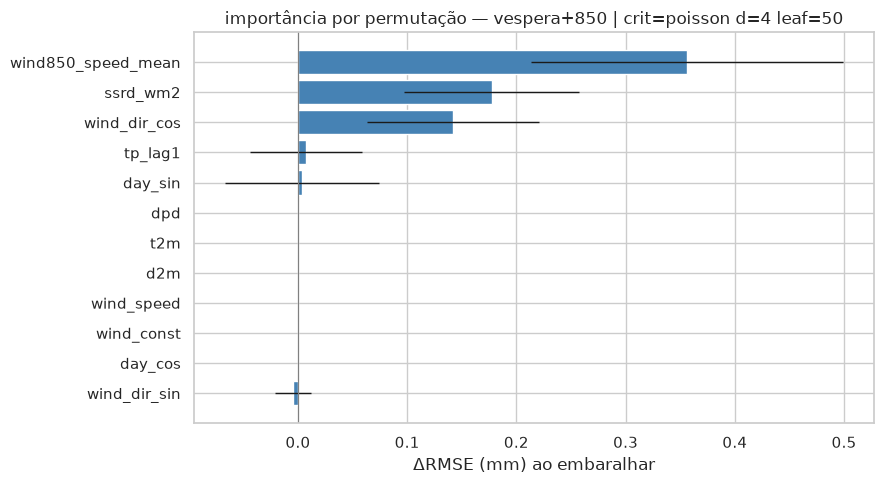

                     media     std
wind850_speed_mean  0.3561  0.1430
ssrd_wm2            0.1773  0.0799
wind_dir_cos        0.1422  0.0786
tp_lag1             0.0076  0.0512
day_sin             0.0038  0.0705
dpd                 0.0000  0.0000
t2m                 0.0000  0.0000
d2m                 0.0000  0.0000
wind_speed          0.0000  0.0000
wind_const          0.0000  0.0000
day_cos             0.0000  0.0000
wind_dir_sin       -0.0044  0.0165

nunca entram em split: ['t2m', 'd2m', 'dpd', 'wind_speed', 'wind_const', 'day_cos']
indistinguível de zero (média < 2×std): ['wind_dir_cos', 'tp_lag1', 'day_sin', 'wind_dir_sin']


In [27]:
from sklearn.inspection import permutation_importance

pi = permutation_importance(final, teste[cols], y_te, n_repeats=20,
                            random_state=SEED, scoring="neg_root_mean_squared_error")
imp = pd.DataFrame({"media": pi.importances_mean, "std": pi.importances_std},
                   index=cols).sort_values("media", ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(imp.index[::-1], imp.media[::-1], xerr=imp["std"][::-1],
        color="steelblue", error_kw={"lw": 1})
ax.axvline(0, color="gray", lw=.8)
ax.set(title=f"importância por permutação — {melhor}", xlabel="ΔRMSE (mm) ao embaralhar")
plt.tight_layout()
salvar("importancia")
plt.show()

print(imp.round(4))
print("\nnunca entram em split:", [c for c, v in zip(cols, final.feature_importances_) if v == 0])
print("indistinguível de zero (média < 2×std):", list(imp[imp.media < 2 * imp["std"]].index))

#### Reprodutibilidade

In [28]:
a = DecisionTreeRegressor(random_state=SEED, **hp).fit(dev[cols], dev.tp_mm).predict(teste[cols])
b = DecisionTreeRegressor(random_state=SEED, **hp).fit(dev[cols], dev.tp_mm).predict(teste[cols])
print("mesma semente, duas rodadas idênticas:", np.array_equal(a, b))

sementes = [rmse(y_te, DecisionTreeRegressor(random_state=s, **hp)
                 .fit(dev[cols], dev.tp_mm).predict(teste[cols])) for s in range(5)]
print(f"RMSE no teste em 5 sementes: {np.round(sementes, 4).tolist()} (desvio {np.std(sementes):.4f})")
print(f"desvio entre folds: {res.loc[melhor, 'RMSE_std']:.3f} | "
      f"diferença entre os 5 melhores do CV: {res.RMSE_cv.nsmallest(5).max() - res.RMSE_cv.min():.3f} mm")

mesma semente, duas rodadas idênticas: True
RMSE no teste em 5 sementes: [10.4175, 10.4175, 10.4175, 10.4175, 10.4175] (desvio 0.0000)
desvio entre folds: 2.476 | diferença entre os 5 melhores do CV: 0.089 mm


In [29]:
import joblib, sklearn

MODELDIR = Path("modelos")
MODELDIR.mkdir(exist_ok=True)
caminho = MODELDIR / "modelo_r10mm.joblib"

joblib.dump({"modelo": final, "features": list(cols), "limiar": LIMIAR, "semente": SEED,
             "hiperparametros": hp, "sklearn": sklearn.__version__,
             "treino_ate": ANO_CORTE, "alvo": "tp_mm"}, caminho)

pac = joblib.load(caminho)
p_rec = pac["modelo"].predict(teste[pac["features"]])
print(f"salvo em {caminho} | features na ordem: {pac['features'] == list(cols)} | "
      f"previsão idêntica: {np.array_equal(p_fin, p_rec)} | sklearn {pac['sklearn']}")

salvo em modelos/modelo_r10mm.joblib | features na ordem: True | previsão idêntica: True | sklearn 1.9.0


**Decisões**

| | decisão | por quê |
|---|---|---|
| Limiar | 10 mm/dia (`R10mm`, ETCCDI) | 2.395 dias (1.857 dev / 538 teste), 65% da chuva. Usar "dia de chuva forte", não "extremo": o extremo para Curitiba é o p99, 48,6 mm (Goudard & Mendonça, 2020) |
| Base do percentil | dias chuvosos (≥ 1 mm) | como no ETCCDI. O p99 sobre dias chuvosos (46,6 mm) reproduz os 48,6 mm publicados; sobre todos os dias daria 36,0 mm |
| Agrupamento | manter todos os dias ≥ 10 mm | autocorrelação residual na subamostra 0,065; declusterizar custaria 33% dos dados e mudaria o alvo para "pico do episódio". Declarar θ junto dos intervalos |
| Acumulados | faixas disjuntas | `tp_sum7/30/90` são aninhados e colineares por construção (Aas et al., 2021) |
| Folds | por data | `test_size=365*4` conta linhas, não anos |
| Climatologia | média mensal, refeita na subamostra | 12 parâmetros; a da série completa aplicada ao teste filtrado dá RMSE 17,7 |
| Modelo | árvore única | interpretável por construção (Rudin, 2019) |
| Outras cidades | não | sem tendência significativa nos índices de precipitação do Paraná (Silva et al., 2015) |

**Seleção de features.** 40 → 29 por redundância cega ao alvo (`|r| > 0,85`): saem `cape_mean`, `tcwv_max`, `wind850_speed_max`, `q850_mean`, `t2m_min`, `t2m_max`, `d2m_lag3`, `wind_max` e as três faixas (autocorrelação 0,92–0,995, não distinguem dias vizinhos). 29 → 20 sem as 9 de importância zero em todos os folds (na CV, as 29 e as 20 deram o mesmo RMSE_cv, 11,583 mm, por isso o conjunto de 29 não é mais avaliado). Apertar para `|r| > 0,60` piora o CV (11,656 × 11,583), e selecionar por correlação com o alvo piorou o teste.

**Resultado.** Condicionar em dia forte destrói o sinal marginal: `tp_lag1` cai de 0,54 para 0,08, `ssrd_wm2` vira a mais forte e `d2m`/`t2m` trocam de sinal. Nenhum modelo da grade é distinguível do melhor no teste pareado, nem a árvore de uma folha; o entregue é o melhor do CV, com essa limitação declarada. O teto da previsão fica muito abaixo do observado: uma folha prevê a média dos seus dias.

**Em aberto.** Explicabilidade local (SHAP); o ERA5-Land tem cerca de metade dos dias extremos do pluviômetro (78 acima de 47,3 mm em 1980–2025 contra 132 acima de 48,6 mm em Goudard & Mendonça); corrigir o atv2 para a climatologia mensal (7,243 mm, ganho de 6,0% em vez de 7,4%).

**Referências.** ETCCDI ([definições](https://etccdi.pacificclimate.org/docs/ETCCDMIndicesComparison1.pdf)) · Goudard & Mendonça (2020), *IdeAs* 15, [doi:10.4000/ideas.8082](https://doi.org/10.4000/ideas.8082) · Silva et al. (2015), *RBMet* 30(2) ([SciELO](http://www.scielo.br/j/rbmet/a/G5w6XK4sLCFkJYNs8SFjgcn/?lang=pt)) · Rudin (2019), *Nat. Mach. Intell.* 1, [doi:10.1038/s42256-019-0048-x](https://doi.org/10.1038/s42256-019-0048-x) · Aas et al. (2021), *Artif. Intell.* 298, [doi:10.1016/j.artint.2021.103502](https://doi.org/10.1016/j.artint.2021.103502) · Ferro & Segers (2003), *JRSS-B* 65(2) ([PDF](https://mistis.inrialpes.fr/docs/EXTREMES/Ferro2003.pdf))